In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/mlp-term-2-2025-kaggle-assignment-2/sample_submission.csv
/kaggle/input/mlp-term-2-2025-kaggle-assignment-2/train.csv
/kaggle/input/mlp-term-2-2025-kaggle-assignment-2/test.csv


# Assignment 2

In this assignment your task is to predict whether the customer of a financial institution exits or stays. You will be provided with a training dataset and a test dataset. The labels for the test dataset will remain hidden and your task is to submit predictions for the same.

In [2]:
#Importing Required Modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import f1_score ,classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
from sklearn.linear_model import RidgeClassifier, Perceptron, SGDClassifier, LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from lightgbm import LGBMClassifier

In [3]:
#Dataset Loading
df_train=pd.read_csv("/kaggle/input/mlp-term-2-2025-kaggle-assignment-2/train.csv")
df_test=pd.read_csv("/kaggle/input/mlp-term-2-2025-kaggle-assignment-2/test.csv")
sample_submission=pd.read_csv("/kaggle/input/mlp-term-2-2025-kaggle-assignment-2/sample_submission.csv")

# Explanatory Data Analysis 

In [4]:
df_train.shape

(90000, 14)

In [5]:
df_train.columns

Index(['id', 'customer_id', 'last_name', 'credit_score', 'country', 'gender',
       'age', 'tenure', 'acc_balance', 'prod_count', 'has_card', 'is_active',
       'estimated_salary', 'exit_status'],
      dtype='object')

In [6]:
df_train.head(n=10)

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,id,customer_id,last_name,credit_score,country,gender,age,tenure,acc_balance,prod_count,has_card,is_active,estimated_salary,exit_status
0,0,15788291,Iredale,559.0,France,Male,28.0,1,149989.39,1.0,1.0,1.0,67622.46,0
1,1,15642816,Hs?,694.0,France,Female,37.0,7,114510.35,2.0,0.0,0.0,182797.86,0
2,2,15632272,T'ien,585.0,NaN,Female,45.0,8,NaN,2.0,1.0,1.0,170338.35,0
3,3,15685826,Hightower,589.0,Spain,Male,25.0,0,166082.18,1.0,1.0,1.0,166476.46,0
4,4,15658032,Hopkins,701.0,France,Male,39.0,2,0.00,2.0,1.0,0.0,82526.92,0
5,5,15650924,Ch'ien,587.0,France,Male,36.0,1,171770.55,1.0,1.0,1.0,70954.66,0
6,6,15786905,Russo,749.0,Germany,Female,40.0,8,141782.57,2.0,1.0,0.0,86333.63,0
7,7,15756920,Ch'iu,712.0,Spain,Male,40.0,8,NaN,2.0,0.0,1.0,5791.85,0
8,8,15681410,Chikwendu,NaN,Germany,Male,49.0,8,NaN,1.0,1.0,0.0,152884.85,1
9,9,15742681,Onwuamaeze,769.0,France,Male,38.0,4,106938.11,1.0,1.0,0.0,173516.71,0


In [7]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90000 entries, 0 to 89999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                90000 non-null  int64  
 1   customer_id       90000 non-null  int64  
 2   last_name         90000 non-null  object 
 3   credit_score      80444 non-null  float64
 4   country           83979 non-null  object 
 5   gender            90000 non-null  object 
 6   age               90000 non-null  float64
 7   tenure            90000 non-null  int64  
 8   acc_balance       82743 non-null  float64
 9   prod_count        85137 non-null  float64
 10  has_card          90000 non-null  float64
 11  is_active         90000 non-null  float64
 12  estimated_salary  90000 non-null  float64
 13  exit_status       90000 non-null  int64  
dtypes: float64(7), int64(4), object(3)
memory usage: 9.6+ MB


In [8]:
df_train.isna().sum()

id                     0
customer_id            0
last_name              0
credit_score        9556
country             6021
gender                 0
age                    0
tenure                 0
acc_balance         7257
prod_count          4863
has_card               0
is_active              0
estimated_salary       0
exit_status            0
dtype: int64

**Observations:**

1. The training dataset has 90000 samples and 14 features
2. The features are : id ,customer_id ,last_name ,credit_score ,country ,gender ,age ,tenure ,acc_balance ,prod_count ,has_card ,is_active ,estimated_salary ,exit_status. Out of which exit_status is the target feature.
3. There seem to be missing data in the features credit_score, country, acc_balance and has_card.
4. Basic info about features:
      * id (int64) - The index column
      * customer_id (int64) - A unique identifier for each customer
      * last_name (object) - The last name of the customer
      * credit_score (float64) - Credit score of the customer
      * country (object) - Country of residence of the customer
      * gender (object) - Gender of the customer
      * age (float64) - Age of the customer
      * tenure (int64) - Years of association with the financial institution
      * acc_balance (float64) - Account balance of the customer
      * prod_count (float64) - Number of products of the financial institution used                                by the customer
      * has_card (float64) - Ownership of credit card by the customer
      * is_active (float64) - Recent activity indicator of the customer
      * estimated_salary (float64) - Estimated salary of the customer
      * exit_status (int64) - Has the customer exit
   

# Descriptive Statistcs

In [9]:
df_train.describe()

,id,customer_id,credit_score,age,tenure,acc_balance,prod_count,has_card,is_active,estimated_salary,exit_status
count,90000.000000,9.000000e+04,80444.000000,90000.000000,90000.000000,82743.000000,85137.000000,90000.000000,90000.000000,90000.000000,90000.000000
mean,44999.500000,1.569209e+07,656.497054,38.119533,5.017022,55456.732147,1.552932,0.754289,0.497178,112394.659679,0.211600
std,25980.906451,7.129796e+04,80.016856,8.855203,2.804813,62788.474236,0.548011,0.430510,0.499995,50360.440702,0.408445
min,0.000000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,11.580000,0.000000
25%,22499.750000,1.563361e+07,597.000000,32.000000,3.000000,0.000000,1.000000,1.000000,0.000000,74430.360000,0.000000
50%,44999.500000,1.569016e+07,659.000000,37.000000,5.000000,0.000000,2.000000,1.000000,0.000000,117505.070000,0.000000
75%,67499.250000,1.575674e+07,710.000000,42.000000,7.000000,119825.750000,2.000000,1.000000,1.000000,154874.787500,0.000000
max,89999.000000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.000000,1.000000,199992.480000,1.000000


In [10]:
df_train.describe(include='object')

,last_name,country,gender
count,90000,83979,90000
unique,2611,3,2
top,Hsia,France,Male
freq,1343,47966,50914


In [11]:
df_train['exit_status'].value_counts(normalize=True)

exit_status
0    0.7884
1    0.2116
Name: proportion, dtype: float64

**Observations:**

1. id ranges from 0 to 89,999 — likely just a row index.
2. credit_score has range: 350 to 850 (typical credit score scale).25% of customers have scores ≤597; 75% have ≤710 — suggesting some right skew.
Missing in ~9.5% of rows — needs imputation or handling.
3. Customers a mix of young and middle-aged adults, older customers are relatively few as indicated by age.
4. acc_balance has mean: ₹55,456, but 25%, 50% percentiles = ₹0 which indicates at least 50% of users have zero balance.75%: ₹119,825 shows right-skewed distribution. Missing in ~7% rows — may be inactive or new accounts.
5. has_card mean ~75% i.e. 75% of customers have a credit/debit card.
6. is_active mean ~49% i.e. half of customers are active.
7. estimated salaray has huge variance but distribution seems fairly uniform (no concentration around quartiles).
8. exit_status is imbalanced ~79% stayed, 21% left. Resampling techniques probably required.
9. last_name has high cardinality but doesnot seem to be very useful.
10. country has ~6.7% missing values which can be imputed or replaced with unknown.

In [12]:
#id and last_name can be dropped as they seem to not be useful
df_train.drop(columns=['id','last_name'],inplace=True,axis=1)

# Handling missing values

In [13]:
mf_si=SimpleImputer(strategy='most_frequent')
median_si=SimpleImputer(strategy='median')
    
df_train['prod_count']=mf_si.fit_transform(df_train[['prod_count']]).ravel()
df_train['credit_score']=median_si.fit_transform(df_train[['credit_score']]).ravel()
df_train['acc_balance']=median_si.fit_transform(df_train[['acc_balance']]).ravel()

In [14]:
df_train['country'].replace(np.nan, 'unknown', inplace=True)

/tmp/ipykernel_13/558314893.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_train['country'].replace(np.nan, 'unknown', inplace=True)


In [15]:
df_train.isna().sum()

customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
acc_balance         0
prod_count          0
has_card            0
is_active           0
estimated_salary    0
exit_status         0
dtype: int64

**Observations:**

1. Imputed prod_count with most_frequent.
2. Replaced np.nan with unknown in country.
3. Dropped np.nan rows in credit_score and acc_balance as imputing them might give completely incorrect values.Before dropping checked whether it affects the the skew of exit_status (for us , it doesnot) and also we still retain ~ 82% of the data, so dropping is safe.

# Handling Duplicates

In [16]:
def check_duplicates(df):
    duplicate_rows = df[df.duplicated()]
    num_duplicates = duplicate_rows.shape[0]
    print(f"Number of duplicate rows: {num_duplicates}")
    if num_duplicates > 0:
        print("Here are the duplicate rows:")
        print(duplicate_rows)
    return duplicate_rows

duplicates = check_duplicates(df_train)

Number of duplicate rows: 9
Here are the duplicate rows:
       customer_id  credit_score  country  gender   age  tenure  acc_balance  \
11438     15591248         628.0   France  Female  29.0       9     71996.29   
38662     15623082         507.0   France  Female  35.0       3         0.00   
41434     15672798         656.0   France  Female  45.0       7         0.00   
43665     15809462         656.0   France    Male  30.0       3         0.00   
44995     15724838         599.0   France  Female  43.0       4         0.00   
51738     15660429         665.0    Spain  Female  42.0       2    156371.61   
56392     15628008         781.0    Spain  Female  29.0       6     98759.89   
59053     15773804         625.0   France    Male  39.0       5         0.00   
75072     15603880         519.0  Germany    Male  38.0       1    114141.64   

       prod_count  has_card  is_active  estimated_salary  exit_status  
11438         2.0       1.0        0.0          34857.46            0 

In [17]:
df_train = df_train.drop_duplicates()

In [18]:
df_train.duplicated().sum()

0

**Observations:**

The function check_ duplicates checks for duplicate rows in df_train and returns them. Here we see that there are no duplicate rows.

# Handling Outliers

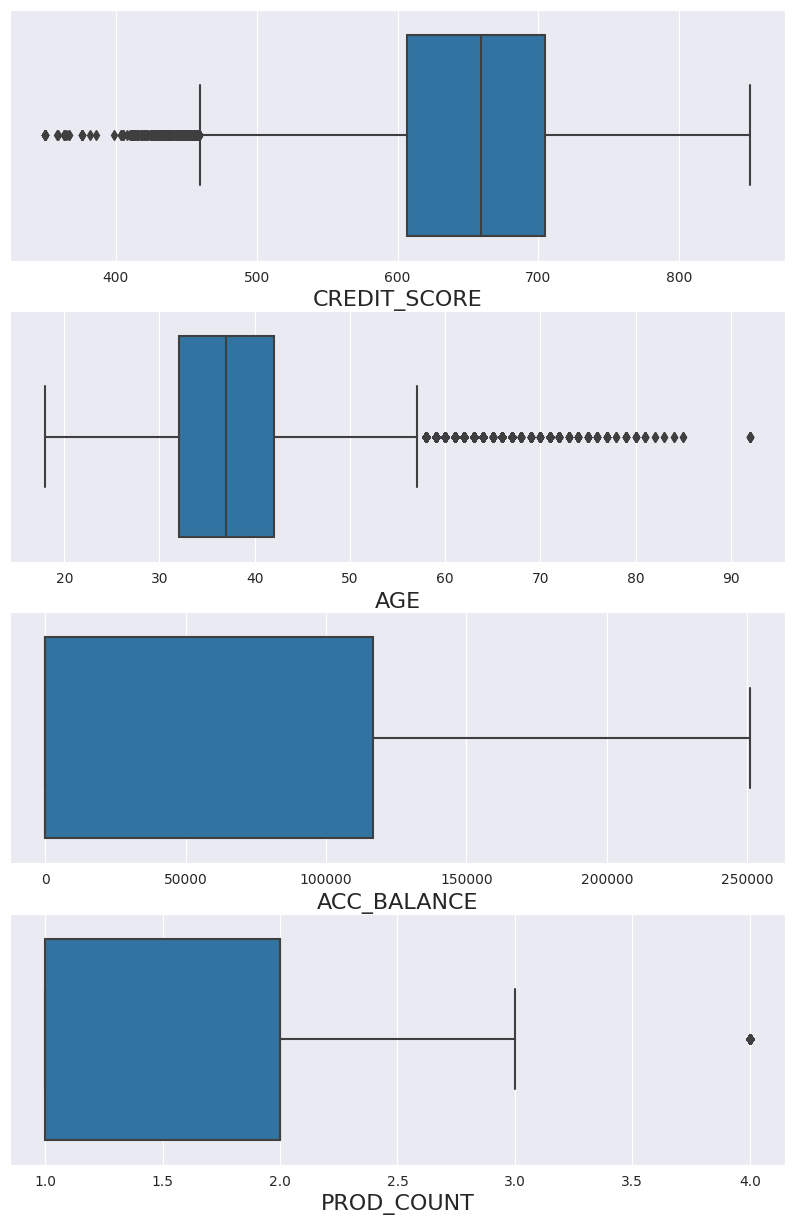

In [19]:
cols = ['credit_score','age','acc_balance','prod_count']
plt.figure(figsize = (10,15))
sns.set_style('darkgrid')
for i in range(len(cols)):
    plt.subplot(4,1,i+1)
    sns.boxplot(data = df_train,x = cols[i])
    plt.xlabel(cols[i].upper(),fontsize = 16)
plt.show()

In [20]:
def detect_outliers_iqr(column_name):
  Q1=df_train[column_name].quantile(0.25)
  Q3=df_train[column_name].quantile(0.75)
  IQR=Q3-Q1
  lower_bound=Q1-1.5*IQR
  upper_bound=Q3+1.5*IQR
  outliers=df_train[(df_train[column_name]<lower_bound) | (df_train[column_name]>upper_bound)]
  return outliers

In [21]:
outlier_values1 = detect_outliers_iqr('credit_score')['credit_score']
print("Number of outlier values:", outlier_values1.count())
print("Mean of outliers:", outlier_values1.mean())
print("Max of outliers:", outlier_values1.max())
print("Min of outliers:", outlier_values1.min())
print("How far beyond upper bound:", outlier_values1.sort_values(ascending=False).head())

Number of outlier values: 605
Mean of outliers: 436.51570247933887
Max of outliers: 459.0
Min of outliers: 350.0
How far beyond upper bound: 13396    459.0
65781    459.0
54704    459.0
79913    459.0
56272    459.0
Name: credit_score, dtype: float64


In [22]:
outlier_values2 = detect_outliers_iqr('age')['age']
print("Number of outlier values:", outlier_values2.count())
print("Mean of outliers:", outlier_values2.mean())
print("Max of outliers:", outlier_values2.max())
print("Min of outliers:", outlier_values2.min())
print("How far beyond upper bound:", outlier_values2.sort_values(ascending=False).head())

Number of outlier values: 3411
Mean of outliers: 63.22368806801524
Max of outliers: 92.0
Min of outliers: 58.0
How far beyond upper bound: 85635    92.0
19729    92.0
32141    92.0
57283    92.0
23647    92.0
Name: age, dtype: float64


In [23]:
outlier_values3 = detect_outliers_iqr('prod_count')['prod_count']
print("Number of outlier values:", outlier_values3.count())
print("Mean of outliers:", outlier_values3.mean())
print("Max of outliers:", outlier_values3.max())
print("Min of outliers:", outlier_values3.min())
print("How far beyond upper bound:", outlier_values3.sort_values(ascending=False).head())

Number of outlier values: 263
Mean of outliers: 4.0
Max of outliers: 4.0
Min of outliers: 4.0
How far beyond upper bound: 61       4.0
53356    4.0
53998    4.0
54213    4.0
54345    4.0
Name: prod_count, dtype: float64


**Observations:**

From df_train.describe(), we select the columns which are most likely to have outliers and check for its existence.
1. By graph we can see that acc_balance has no outliers.
2. credit_score has 115 outliers but no impossible values such as negative values or seem to be data erros.They are mostly low credit score (lower bound outliers) which is possible and removing them could impact our model negatively.
3. age has 470 outliers , mostly higher bound outliers.All outliers donot have any impossible value and could be data entry erros. So, i choose to keep them
4. prod_count has 214 outliers all of which values are 4, this is entirely possible and hence I'm keeping it.

# Visualization

Text(0.5, 0, 'Exit Status')

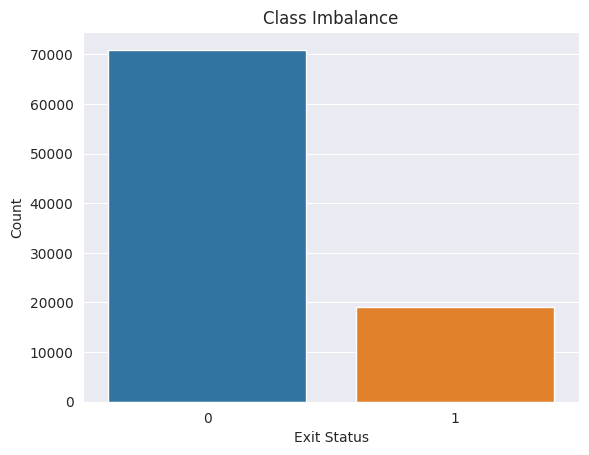

In [24]:
sns.countplot(x='exit_status', data=df_train)
plt.title('Class Imbalance')
plt.ylabel('Count')
plt.xlabel('Exit Status')

**Observations:**

As we already know there is an imbalance in the exit_status target column . Here we have plot of the same.
We will deal with imbalance by adding stratify=y in train_test_split and class_weight='balanced' during modelling.

Text(0.5, 1.0, 'Correlation Heatmap')

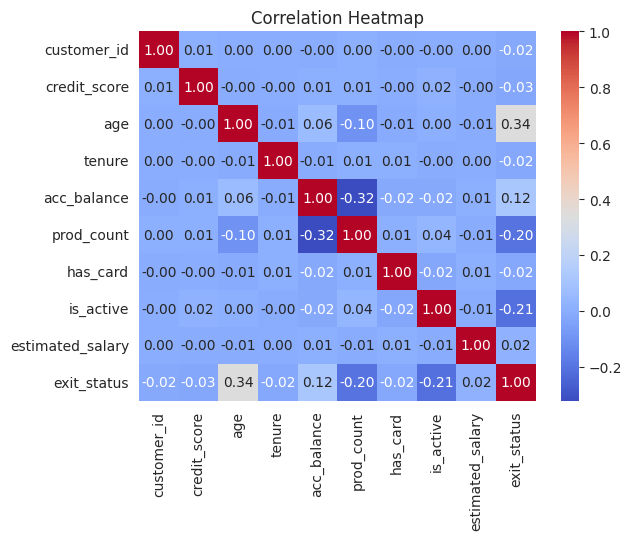

In [25]:
#Correlation heatmap
cols=df_train.select_dtypes(include=['number']).columns
sns.heatmap(df_train[cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')

**Observations:**

There doesnot seem to very high correlation between any of the features.
There are only 2 notable ones exit_status and age with 0.34 and prod_count and acc_balance with -0.35 but they still relatively low.

Text(0.5, 0, 'Country')

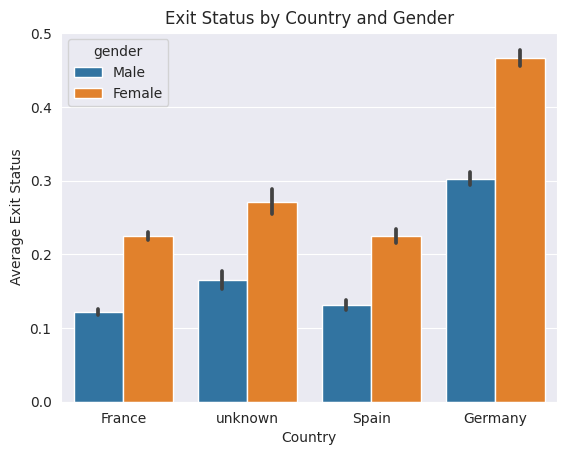

In [26]:
sns.barplot(x='country', y='exit_status', hue='gender', data=df_train)
plt.title('Exit Status by Country and Gender')
plt.ylabel('Average Exit Status')
plt.xlabel('Country')

**Observations:**

1. Germans (especially females) seem to leaving the most.
2. France seems to have lowest exit rate followed closely by Spain.
3. Generally Females seem to exit at a much higher rate than men in all countries.

# Scaling and Encoding

In [27]:
X=df_train.drop(columns='exit_status')
y=df_train['exit_status']

num_cols=X.select_dtypes(include=['number']).columns
cat_cols=X.select_dtypes(include=['object','bool']).columns

num_pipeline=Pipeline(steps=[
    ('scaler',StandardScaler())
])

cat_pipeline=Pipeline(steps=[
    ('encoder',OneHotEncoder(handle_unknown='ignore'))
])

preprocessor=ColumnTransformer([
    ('num',num_pipeline,num_cols),
    ('cat',cat_pipeline,cat_cols)
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

X_train_transformed=preprocessor.fit_transform(X_train)
X_test_transformed=preprocessor.transform(X_test)

**Observations:**

We separate the df_train into X(features) and y(labels) Scaling with StandardScaler() is performed on the numerical columns. OneHotEncoding() is performed on categorical columns as most have few unique values.
stratify=y added during train_test_split to ensure that the training and testing sets have the same proportion of classes (or labels) as the original dataset.

# Model Building

**Model 1 - RidgeClassifier**

In [28]:
ridge = RidgeClassifier(class_weight='balanced',random_state=42)
ridge.fit(X_train_transformed, y_train)

y_train_pred1 = ridge.predict(X_train_transformed)
y_ridge_pred = ridge.predict(X_test_transformed)

print("RidgeClassifier:")
print(f"Train F1 Score: {f1_score(y_train, y_train_pred1, average='weighted'):.3f}")
print(f"Test F1 Score: {f1_score(y_test, y_ridge_pred, average='weighted'):.3f}")

RidgeClassifier:
Train F1 Score: 0.773
Test F1 Score: 0.770


              precision    recall  f1-score   support

           0      0.909     0.762     0.829     14190
           1      0.447     0.715     0.550      3809

    accuracy                          0.752     17999
   macro avg      0.678     0.739     0.689     17999
weighted avg      0.811     0.752     0.770     17999



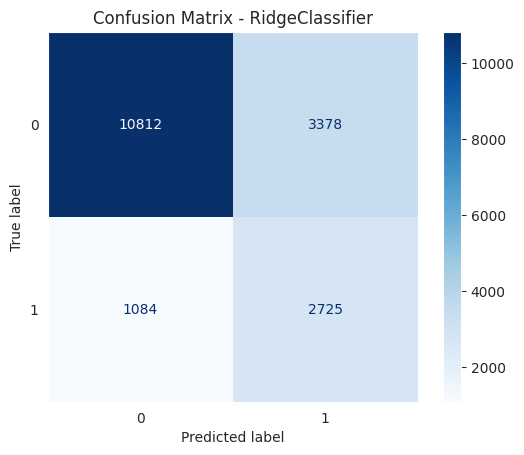

In [29]:
print(classification_report(y_test, ridge.predict(X_test_transformed), digits=3))
ConfusionMatrixDisplay.from_estimator(ridge, X_test_transformed, y_test, cmap='Blues')
plt.title("Confusion Matrix - RidgeClassifier")
plt.grid(False)
plt.show()

**Model 2 - Perceptron**

In [30]:
perceptron = Perceptron(class_weight='balanced', random_state=42)
perceptron.fit(X_train_transformed, y_train)

y_train_pred2 = perceptron.predict(X_train_transformed)
y_percep_pred = perceptron.predict(X_test_transformed)

print("Perceptron:")
print(f"Train F1 Score: {f1_score(y_train, y_train_pred2, average='weighted'):.3f}")
print(f"Test F1 Score: {f1_score(y_test, y_percep_pred, average='weighted'):.3f}")

Perceptron:
Train F1 Score: 0.691
Test F1 Score: 0.689


              precision    recall  f1-score   support

           0      0.897     0.640     0.747     14190
           1      0.351     0.725     0.473      3809

    accuracy                          0.658     17999
   macro avg      0.624     0.683     0.610     17999
weighted avg      0.781     0.658     0.689     17999



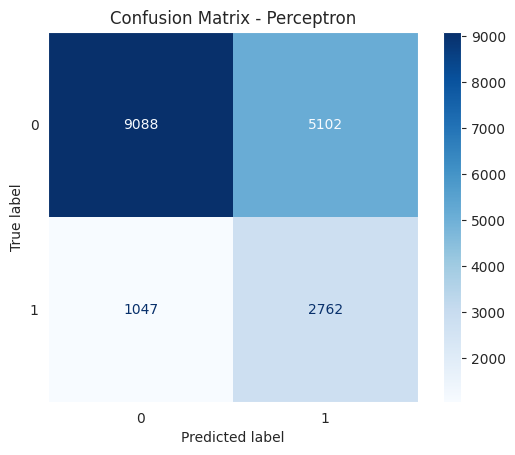

In [31]:
print(classification_report(y_test, perceptron.predict(X_test_transformed), digits=3))
ConfusionMatrixDisplay.from_estimator(perceptron, X_test_transformed, y_test, cmap='Blues')
plt.title("Confusion Matrix - Perceptron")
plt.grid(False)
plt.show()

**Model 3 - SGDClassifier**

In [32]:
sgd = SGDClassifier(loss='modified_huber', class_weight='balanced', random_state=42)
sgd.fit(X_train_transformed, y_train)

y_train_pred3 = sgd.predict(X_train_transformed)
y_sgd_pred = sgd.predict(X_test_transformed)

print("SGDClassifier:")
print(f"Train F1 Score: {f1_score(y_train, y_train_pred3, average='weighted'):.3f}")
print(f"Test F1 Score: {f1_score(y_test, y_sgd_pred, average='weighted'):.3f}")

SGDClassifier:
Train F1 Score: 0.797
Test F1 Score: 0.791


              precision    recall  f1-score   support

           0      0.892     0.822     0.856     14190
           1      0.487     0.627     0.548      3809

    accuracy                          0.781     17999
   macro avg      0.689     0.725     0.702     17999
weighted avg      0.806     0.781     0.791     17999



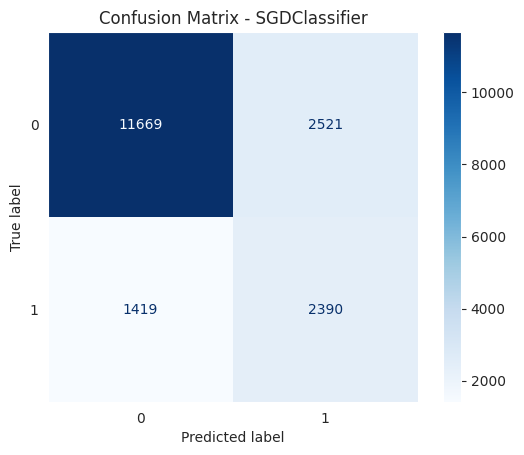

In [33]:
print(classification_report(y_test, sgd.predict(X_test_transformed), digits=3))
ConfusionMatrixDisplay.from_estimator(sgd, X_test_transformed, y_test, cmap='Blues')
plt.title("Confusion Matrix - SGDClassifier")
plt.grid(False)
plt.show()

**Model 4 - RandomForestClassifier**

In [34]:
rf = RandomForestClassifier(class_weight='balanced',random_state=42)
rf.fit(X_train_transformed, y_train)

y_train_pred4 = rf.predict(X_train_transformed)
y_rf_pred = rf.predict(X_test_transformed)

print("RandomForestClassifier:")
print(f"Train F1 Score: {f1_score(y_train, y_train_pred4, average='weighted'):.3f}")
print(f"Test F1 Score: {f1_score(y_test, y_rf_pred, average='weighted'):.3f}")

RandomForestClassifier:
Train F1 Score: 1.000
Test F1 Score: 0.843


              precision    recall  f1-score   support

           0      0.874     0.954     0.912     14190
           1      0.741     0.486     0.587      3809

    accuracy                          0.855     17999
   macro avg      0.807     0.720     0.750     17999
weighted avg      0.846     0.855     0.843     17999



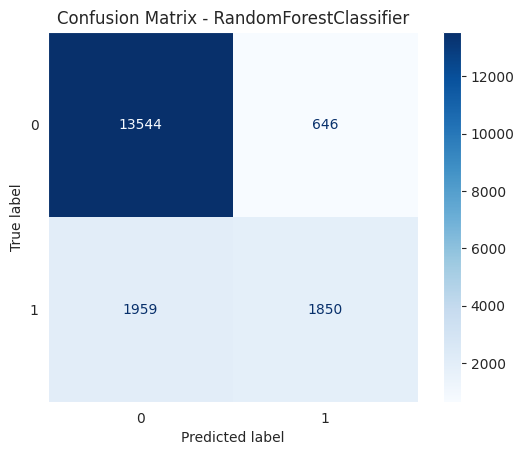

In [35]:
print(classification_report(y_test, rf.predict(X_test_transformed), digits=3))
ConfusionMatrixDisplay.from_estimator(rf, X_test_transformed, y_test, cmap='Blues')
plt.title("Confusion Matrix - RandomForestClassifier")
plt.grid(False)
plt.show()

**Model 5 - LogisticRegression**

In [36]:
logreg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
logreg.fit(X_train_transformed, y_train)

y_train_pred5 = logreg.predict(X_train_transformed)
y_logreg_pred = logreg.predict(X_test_transformed)

print("LogisticRegression:")
print(f"Train F1 Score: {f1_score(y_train, y_train_pred5, average='weighted'):.3f}")
print(f"Test F1 Score: {f1_score(y_test, y_logreg_pred, average='weighted'):.3f}")

LogisticRegression:
Train F1 Score: 0.771
Test F1 Score: 0.768


              precision    recall  f1-score   support

           0      0.892     0.822     0.856     14190
           1      0.487     0.627     0.548      3809

    accuracy                          0.781     17999
   macro avg      0.689     0.725     0.702     17999
weighted avg      0.806     0.781     0.791     17999



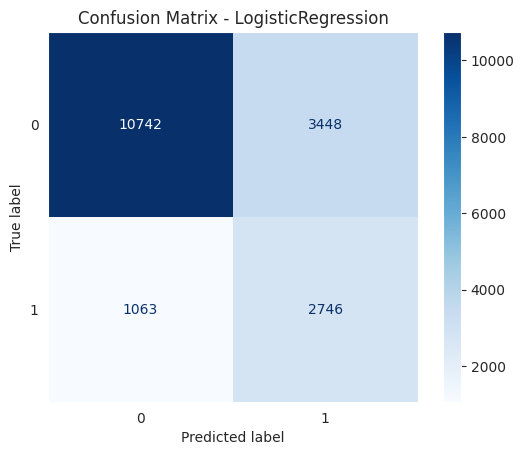

In [37]:
print(classification_report(y_test, sgd.predict(X_test_transformed), digits=3))
ConfusionMatrixDisplay.from_estimator(logreg, X_test_transformed, y_test, cmap='Blues')
plt.title("Confusion Matrix - LogisticRegression")
plt.grid(False)
plt.show()

**Model 6 - LGBMClassifier**

In [38]:
lgbm = LGBMClassifier(is_unbalance=True, random_state=42,verbose=-1)
lgbm.fit(X_train_transformed, y_train)

y_train6_pred = lgbm.predict(X_train_transformed)
y_lgbm_pred = lgbm.predict(X_test_transformed)

print("LGBMClassifier:")
print(f"Train F1 Score: {f1_score(y_train, y_train6_pred, average='weighted'):.3f}")
print(f"Test F1 Score: {f1_score(y_test, y_lgbm_pred, average='weighted'):.3f}")

LGBMClassifier:
Train F1 Score: 0.832
Test F1 Score: 0.822


              precision    recall  f1-score   support

           0      0.930     0.821     0.872     14190
           1      0.536     0.771     0.632      3809

    accuracy                          0.810     17999
   macro avg      0.733     0.796     0.752     17999
weighted avg      0.847     0.810     0.822     17999



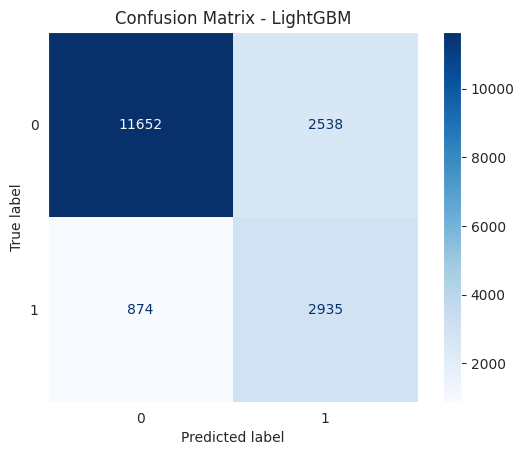

In [39]:
print(classification_report(y_test, lgbm.predict(X_test_transformed), digits=3))
ConfusionMatrixDisplay.from_estimator(lgbm, X_test_transformed, y_test, cmap='Blues')
plt.title("Confusion Matrix - LightGBM")
plt.grid(False)
plt.show()

**Model 7 - LinearSVC**

In [40]:
linear_svc = LinearSVC(class_weight='balanced',max_iter=5000,random_state=42)
linear_svc.fit(X_train_transformed, y_train)

y_train_pred7 = linear_svc.predict(X_train_transformed)
y_lsvc_pred = linear_svc.predict(X_test_transformed)

print("LinearSVC:")
print(f"Train F1 Score: {f1_score(y_train, y_train_pred7, average='weighted'):.3f}")
print(f"Test F1 Score: {f1_score(y_test, y_lsvc_pred, average='weighted'):.3f}")

LinearSVC:
Train F1 Score: 0.772
Test F1 Score: 0.769


              precision    recall  f1-score   support

           0      0.909     0.759     0.828     14190
           1      0.445     0.719     0.549      3809

    accuracy                          0.751     17999
   macro avg      0.677     0.739     0.688     17999
weighted avg      0.811     0.751     0.769     17999



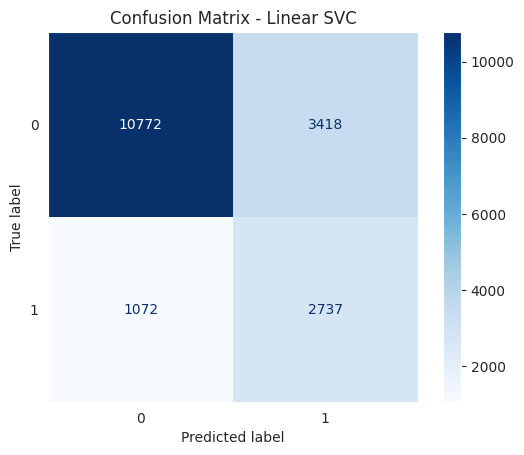

In [41]:
print(classification_report(y_test, linear_svc.predict(X_test_transformed), digits=3))
ConfusionMatrixDisplay.from_estimator(linear_svc, X_test_transformed, y_test, cmap='Blues')
plt.title("Confusion Matrix - Linear SVC")
plt.grid(False)
plt.show()

**Model Comparison:**


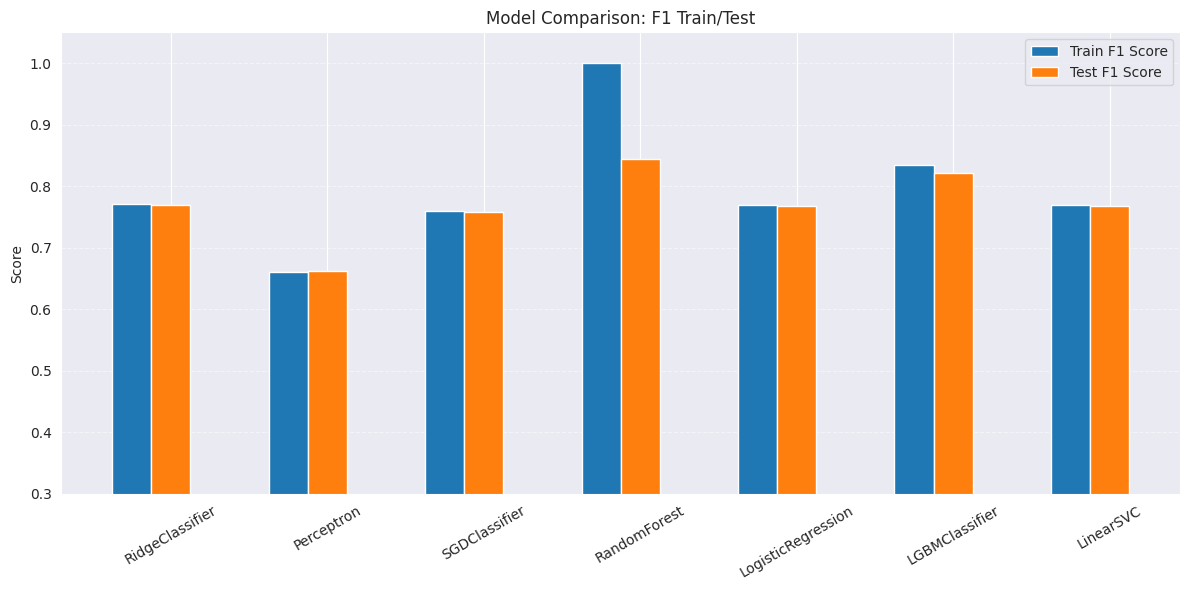

In [42]:
models = ["RidgeClassifier","Perceptron","SGDClassifier","RandomForest","LogisticRegression","LGBMClassifier","LinearSVC"]

train_scores = [0.771, 0.661, 0.760, 1.000, 0.769, 0.835, 0.770]
test_scores =  [0.769, 0.662, 0.758, 0.844, 0.767, 0.822, 0.768]

bar_width = 0.25
x = np.arange(len(models))

plt.figure(figsize=(12, 6))

plt.bar(x - bar_width, train_scores, width=bar_width, label='Train F1 Score')
plt.bar(x, test_scores, width=bar_width, label='Test F1 Score')

plt.xticks(x, models, rotation=30)
plt.ylabel("Score")
plt.title("Model Comparison: F1 Train/Test")
plt.ylim(0.3, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

| Model                  | Train F1 | Test F1 | Class 1 F1 | Class 1 Recall | Class 1 Precision | FN   | FP   |
| ---------------------- | -------- | ------- | ---------- | -------------- | ----------------- | ---- | ---- |
| RidgeClassifier        | 0.771    | 0.769   | 0.551      | 0.724          | 0.445             | 860  | 2827 |
| Perceptron             | 0.661    | 0.662   | 0.347      | 0.462          | 0.278             | 1674 | 3741 |
| SGDClassifier          | 0.760    | 0.758   | 0.539      | 0.729          | 0.428             | 843  | 3034 |
| RandomForestClassifier | 1.000    | 0.844   | 0.590      | 0.493          | 0.733             | 1577 | 559  |
| LogisticRegression     | 0.769    | 0.767   | 0.539      | 0.729          | 0.428             | 843  | 3034 |
| LGBMClassifier         | 0.835    | 0.822   | 0.631      | 0.771          | 0.534             | 711  | 2092 |
| LinearSVC              | 0.770    | 0.768   | 0.549      | 0.725          | 0.441             | 855  | 2856 |


1. RandomForest has the best test f1 but it is overfitting severly and has a low Class 1 Recall.
2. LGBMClassifier, SGDClassifier and LogisticRegression are best at catching churn.
3. Perceptron is the overall worst model.

So from the above observations ,we use the following models for Hyperparameter tuning:
1. LGBMClassifier
2. RidgeClassifier
3. LinearSVC

# HyperParameter Tuning

In [43]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.001,0.01],
    'max_depth': [5, 7],
    'num_leaves': [15, 31]
}

lgbm_search = GridSearchCV(
    estimator=lgbm,
    param_grid=param_grid,
    scoring='f1_weighted',
    cv=3,
    n_jobs=-1,
    verbose=-1
)

lgbm_search.fit(X_train_transformed, y_train)
y_lgbms_pred = lgbm_search.best_estimator_.predict(X_test_transformed)

print("Best Parameters:", lgbm_search.best_params_)
print("Best Estimator:", lgbm_search.best_estimator_)
print("Best mean CV F1:", f"{lgbm_search.best_score_:.3f}")
print("Test F1:", f"{f1_score(y_test, y_lgbms_pred):.3f}")

Best Parameters: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 100, 'num_leaves': 31}
Best Estimator: LGBMClassifier(is_unbalance=True, learning_rate=0.01, max_depth=5,
               random_state=42, verbose=-1)
Best mean CV F1: 0.849
Test F1: 0.633


In [44]:
param_grid = {
    'alpha': [0.001,0.01, 0.1],
    'fit_intercept': [True, False],
    'solver': ['auto', 'sag','saga', 'lsqr']
}

ridge_search = GridSearchCV(
    estimator=ridge,
    param_grid=param_grid,
    scoring='f1_weighted',
    cv=3,
    n_jobs=-1,
    verbose=-1
)

ridge_search.fit(X_train_transformed, y_train)
y_ridges_pred = ridge_search.best_estimator_.predict(X_test_transformed)

print("Best Parameters:", ridge_search.best_params_)
print("Best Estimator:", ridge_search.best_estimator_)
print("Best mean CV F1:", f"{ridge_search.best_score_:.3f}")
print("Test F1:", f"{f1_score(y_test, y_ridges_pred):.3f}")

Best Parameters: {'alpha': 0.001, 'fit_intercept': False, 'solver': 'lsqr'}
Best Estimator: RidgeClassifier(alpha=0.001, class_weight='balanced', fit_intercept=False,
                random_state=42, solver='lsqr')
Best mean CV F1: 0.773
Test F1: 0.550


In [45]:
param_grid = {
    'penalty': ['l2', 'l1', 'elasticnet'],
    'alpha': [0.0001, 0.001, 0.01, 0.1],
    'tol': [1e-3, 1e-4, 1e-5],
    'eta0': [0.01,0.05,0.1]
}

percep_search = GridSearchCV(
    estimator=perceptron,
    param_grid=param_grid,
    scoring='f1_weighted',
    cv=3,
    n_jobs=-1,
    verbose=-1
)

percep_search.fit(X_train_transformed, y_train)
y_perceps_pred = percep_search.best_estimator_.predict(X_test_transformed)

print("Best Parameters:", percep_search.best_params_)
print("Best Estimator:", percep_search.best_estimator_)
print("Best mean CV F1:", f"{percep_search.best_score_:.3f}")
print("Test F1:", f"{f1_score(y_test, y_percep_pred):.3f}")

Best Parameters: {'alpha': 0.01, 'eta0': 0.1, 'penalty': 'elasticnet', 'tol': 0.001}
Best Estimator: Perceptron(alpha=0.01, class_weight='balanced', eta0=0.1, penalty='elasticnet',
           random_state=42)
Best mean CV F1: 0.771
Test F1: 0.473


**Model Comparison**

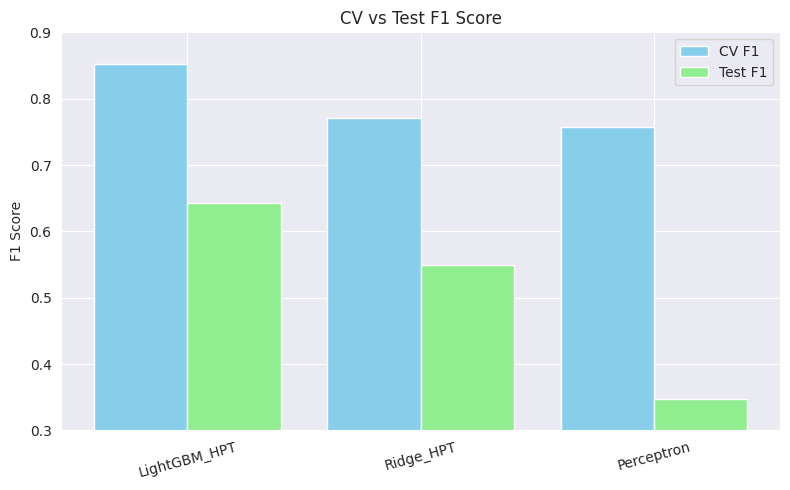

In [46]:
models = ["LightGBM_HPT", "Ridge_HPT", "Perceptron"]
cv_scores = [0.852, 0.771, 0.758]
test_scores = [0.643, 0.550, 0.347]

x = range(len(models))

plt.figure(figsize=(8, 5))
plt.bar(x, cv_scores, width=0.4, label='CV F1', color='skyblue')
plt.bar([i + 0.4 for i in x], test_scores, width=0.4, label='Test F1', color='lightgreen')

plt.xticks([i + 0.2 for i in x], models, rotation=15)
plt.ylabel("F1 Score")
plt.title("CV vs Test F1 Score")
plt.ylim(0.3, 0.9)
plt.legend()
plt.tight_layout()
plt.show()

| Model                     | Best Mean CV F1 | Test F1 Score | Gap (CV - Test) | Comments                                                                     |
| ------------------------- | --------------- | ------------- | --------------- | ---------------------------------------------------------------------------- |
| **LightGBM (HPT)**        |   0.852         |   0.643       |   0.209         | Highest CV and test F1, but some overfitting (21% drop). Still best overall. |
| **RidgeClassifier (HPT)** | 0.771           | 0.550         | 0.221           | Moderate performance, stable but low recall on minority class likely.        |
| **Perceptron**            | 0.758           | 0.347         |   0.411         | Severe overfitting and poor generalization. Not reliable for deployment.     |


Overall , the model we obtained is LightGBM and we proceed to use that for our test data.

# Competition Submission

In [47]:
df_test.drop(columns=['id','last_name'],inplace=True,axis=1)
df_test['prod_count']=mf_si.fit_transform(df_test[['prod_count']]).ravel()
df_test['credit_score']=median_si.fit_transform(df_test[['credit_score']]).ravel()
df_test['acc_balance']=median_si.fit_transform(df_test[['acc_balance']]).ravel()
df_test['country'].replace(np.nan, 'unknown', inplace=True)
print(df_test.isna().sum())
print(check_duplicates(df_train))

customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
acc_balance         0
prod_count          0
has_card            0
is_active           0
estimated_salary    0
dtype: int64
Number of duplicate rows: 0
Empty DataFrame
Columns: [customer_id, credit_score, country, gender, age, tenure, acc_balance, prod_count, has_card, is_active, estimated_salary, exit_status]
Index: []


/tmp/ipykernel_13/3364710222.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_test['country'].replace(np.nan, 'unknown', inplace=True)


In [48]:
#df_train = df_train.drop_duplicates()
#df_test.duplicated.sum()

In [49]:
X_external_test_processed = preprocessor.transform(df_test)
y_external_pred =lgbm_search.best_estimator_.predict(X_external_test_processed)
print(len(sample_submission),len(y_external_pred))
submission = pd.DataFrame({"id": range(0,df_test.shape[0]), "exit_status": y_external_pred})
submission.to_csv('submission.csv',index=False)

30000 30000
